# 01 — Exploratory Data Analysis
**Project:** Santander Customer Transaction Prediction  
**Goal:** Understand the dataset structure, class imbalance, feature distributions, and discriminative power before modeling.  
**Success Metric:** AUC-ROC ≥ 0.90

---
### Notebook Structure
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis (Class Imbalance)
4. Feature Distributions
5. Outlier Analysis
6. Feature–Target Relationship
7. Inter-Feature Correlations
8. EDA Summary & Findings

## 1. Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
DATA_PATH = '../data/train.csv'  # adjust if needed

In [7]:
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c.startswith('var_')]
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Features: {len(feature_cols)}')
df.head(3)

Loaded: 200,000 rows × 202 columns
Features: 200


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965


## 2. Dataset Overview

In [8]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Column Types ===')
print(df.dtypes.value_counts())

print('\n=== Missing Values ===')
missing = df.isnull().sum().sum()
print(f'Total missing cells: {missing}')

print('\n=== Duplicates ===')
print(f'Duplicate rows:    {df.duplicated().sum()}')
print(f'Duplicate ID_code: {df["ID_code"].duplicated().sum()}')

=== Shape ===
Rows: 200,000  |  Columns: 202

=== Column Types ===
float64    200
object       1
int64        1
Name: count, dtype: int64

=== Missing Values ===
Total missing cells: 0

=== Duplicates ===
Duplicate rows:    0
Duplicate ID_code: 0


In [9]:
# Statistical summary of first 10 features
df[feature_cols[:10]].describe().round(3)

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9
count,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000
mean,10.680,-1.628,10.715,6.797,11.078,-5.065,5.409,16.546,0.284,7.567
std,3.040,4.050,2.641,2.043,1.623,7.863,0.867,3.418,3.333,1.235
min,0.408,-15.043,2.117,-0.040,5.075,-32.563,2.347,5.350,-10.506,3.970
25%,8.454,-4.740,8.722,5.254,9.883,-11.200,4.768,13.944,-2.318,6.619
50%,10.525,-1.608,10.580,6.825,11.108,-4.833,5.385,16.457,0.394,7.630
75%,12.758,1.359,12.517,8.324,12.261,0.925,6.003,19.103,2.938,8.584
max,20.315,10.377,19.353,13.188,16.671,17.252,8.448,27.692,10.151,11.151


**Findings:**
- 200,000 rows, 202 columns (ID_code + target + 200 anonymized float features)
- Zero missing values — no imputation needed
- No duplicate rows or IDs
- All features are float64; target is int64 (binary 0/1)

## 3. Target Variable Analysis — Class Imbalance

In [10]:
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True).mul(100).round(2)

print('Target distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percent (%)': target_pct}))
print(f'\nImbalance ratio (negative:positive) = {target_counts[0]/target_counts[1]:.1f}:1')

Target distribution:
         Count  Percent (%)
target                     
0       179902        89.95
1        20098        10.05

Imbalance ratio (negative:positive) = 9.0:1


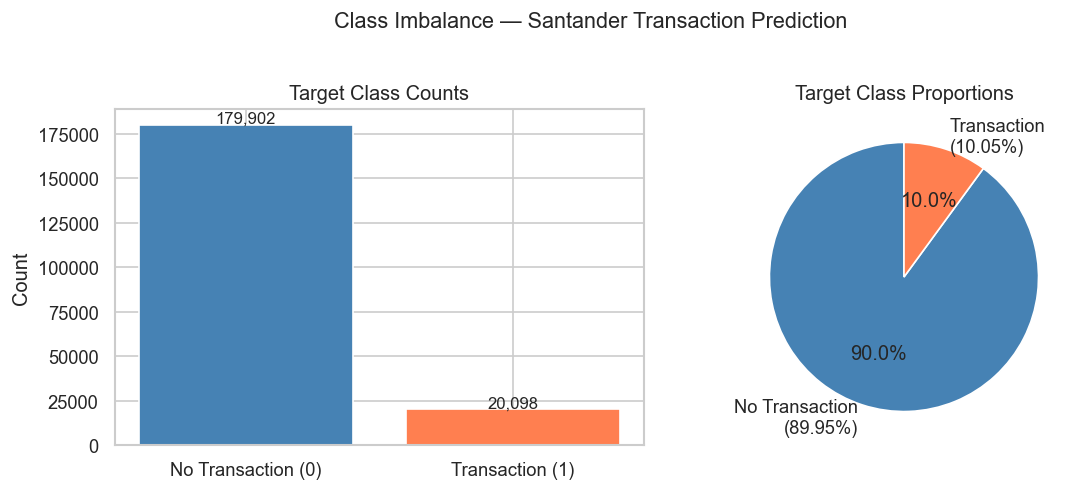

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['No Transaction (0)', 'Transaction (1)'],
            target_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Target Class Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values,
            labels=['No Transaction\n(89.95%)', 'Transaction\n(10.05%)'],
            colors=['steelblue', 'coral'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Class Proportions')

plt.suptitle('Class Imbalance — Santander Transaction Prediction', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks_images/01_class_imbalance.png', bbox_inches='tight')
plt.show()

**Findings:**
- Severe class imbalance: **~90% negative, ~10% positive** (≈9:1 ratio)
- Accuracy is a misleading metric here — a model predicting all-0 gets 90% accuracy
- **AUC-ROC** is the right metric (insensitive to class imbalance)
- Modeling strategies to consider: `class_weight='balanced'`, SMOTE oversampling, or threshold tuning

## 4. Feature Distributions

In [12]:
# Skewness across all 200 features
skewness = df[feature_cols].skew().sort_values()

print(f'Skewness stats across 200 features:')
print(f'  Mean:  {skewness.mean():.4f}')
print(f'  Min:   {skewness.min():.4f}')
print(f'  Max:   {skewness.max():.4f}')
print(f'  |skew| > 1: {(skewness.abs() > 1).sum()} features')
print(f'  |skew| > 0.5: {(skewness.abs() > 0.5).sum()} features')

Skewness stats across 200 features:
  Mean:  0.0122
  Min:   -0.3402
  Max:   0.2674
  |skew| > 1: 0 features
  |skew| > 0.5: 0 features


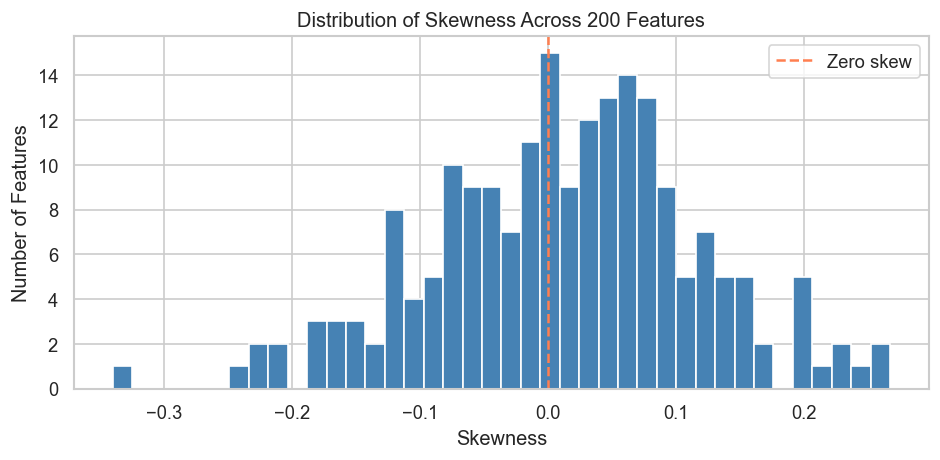

In [13]:
# Distribution of skewness values
plt.figure(figsize=(8, 4))
plt.hist(skewness, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0, color='coral', linestyle='--', label='Zero skew')
plt.title('Distribution of Skewness Across 200 Features')
plt.xlabel('Skewness')
plt.ylabel('Number of Features')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks_images/02_skewness_distribution.png', bbox_inches='tight')
plt.show()

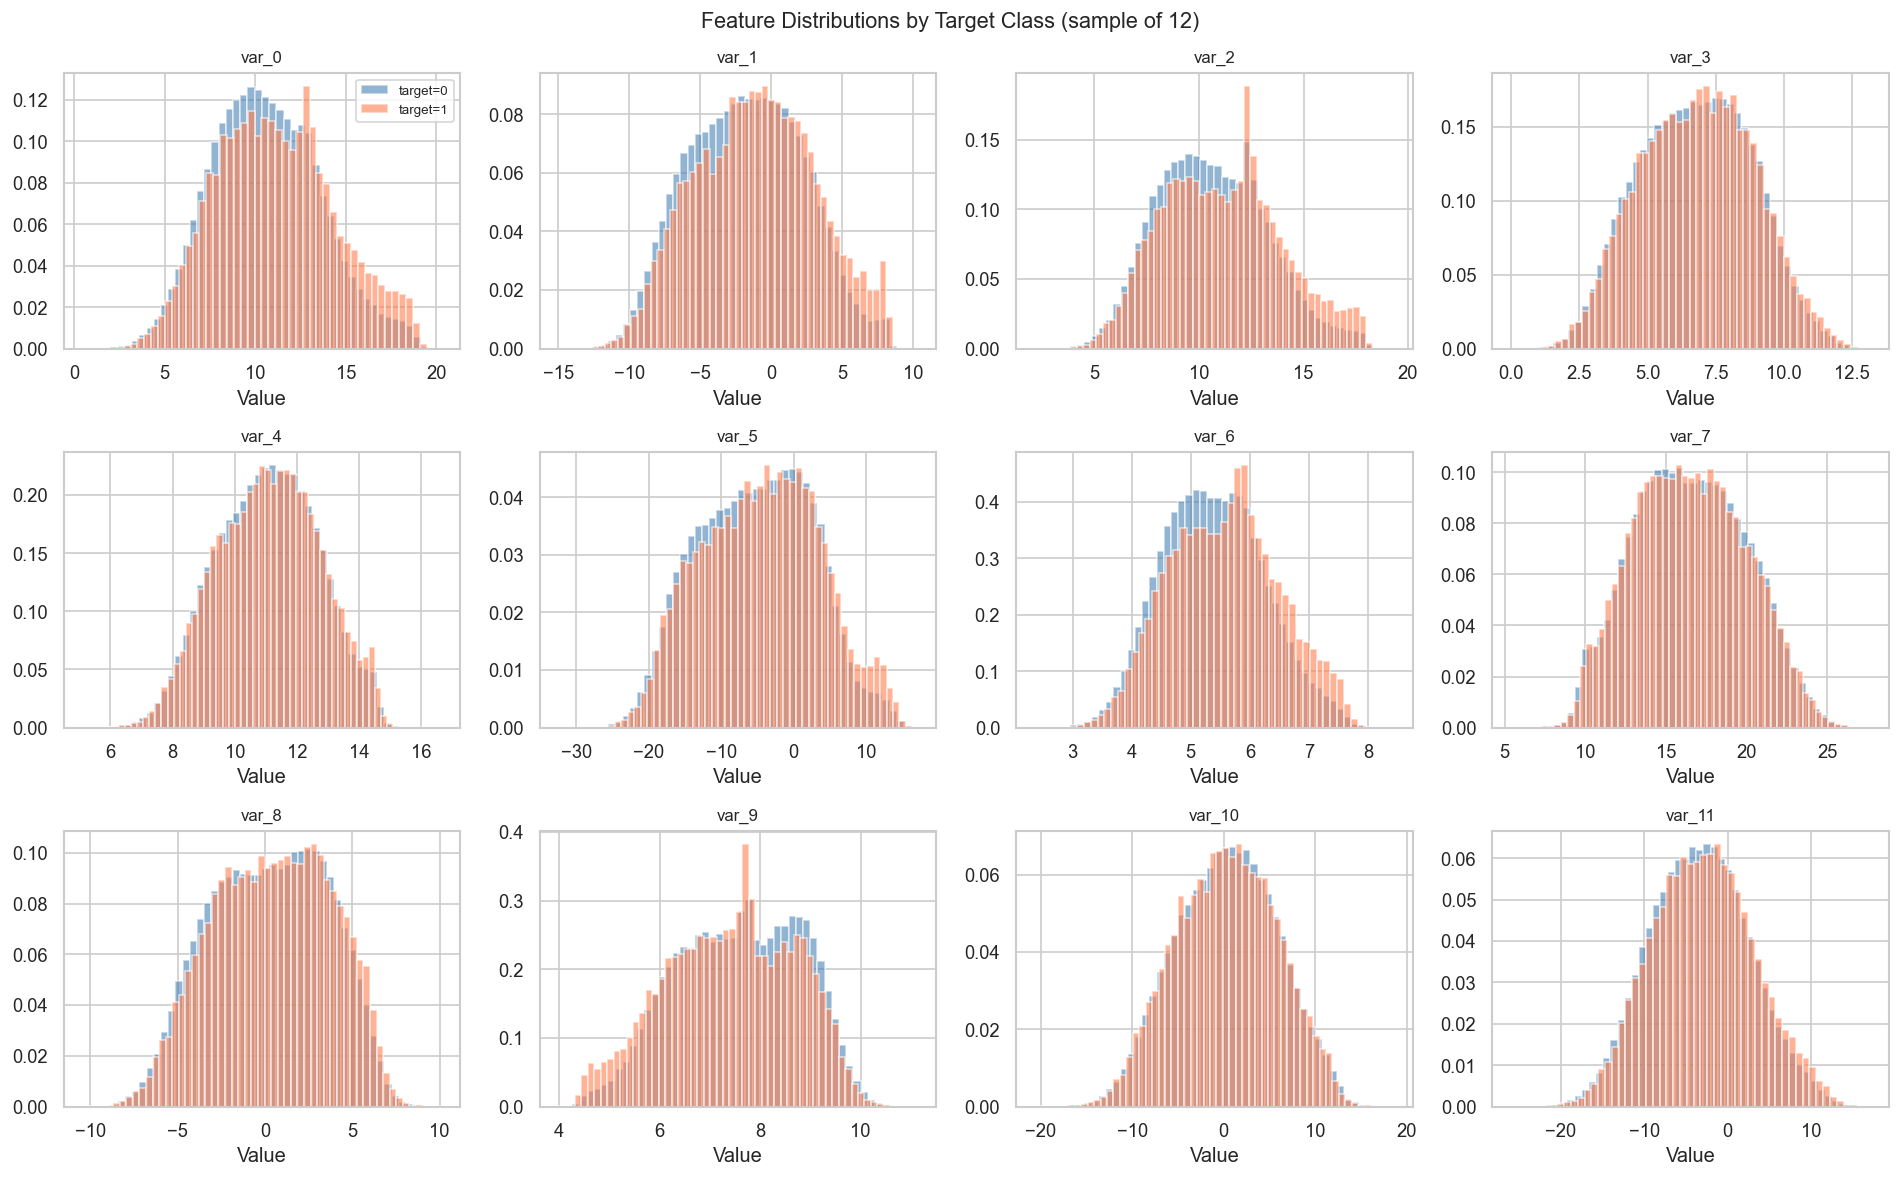

In [14]:
# Sample distributions of 12 features
sample_features = feature_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    axes[i].hist(df[df.target == 0][feat], bins=50, alpha=0.6,
                 color='steelblue', label='target=0', density=True)
    axes[i].hist(df[df.target == 1][feat], bins=50, alpha=0.6,
                 color='coral', label='target=1', density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Target Class (sample of 12)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks_images/03_feature_distributions.png', bbox_inches='tight')
plt.show()

**Findings:**
- All 200 features are approximately **normally distributed** (skewness near 0, no values |skew| > 1)
- **No log transformation needed** — features are already well-behaved
- Some features show visible **distributional shift** between target=0 and target=1 — these will be informative for the model

## 5. Outlier Analysis

In [15]:
# Count outliers per feature using IQR method
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

outlier_counts = df[feature_cols].apply(count_outliers_iqr)
outlier_pct    = (outlier_counts / len(df) * 100).round(2)

print(f'Outlier summary across 200 features (IQR method):')
print(f'  Mean outlier % per feature: {outlier_pct.mean():.2f}%')
print(f'  Max outlier % per feature:  {outlier_pct.max():.2f}% ({outlier_pct.idxmax()})')
print(f'  Features with > 5% outliers: {(outlier_pct > 5).sum()}')

Outlier summary across 200 features (IQR method):
  Mean outlier % per feature: 0.07%
  Max outlier % per feature:  0.75% (var_179)
  Features with > 5% outliers: 0


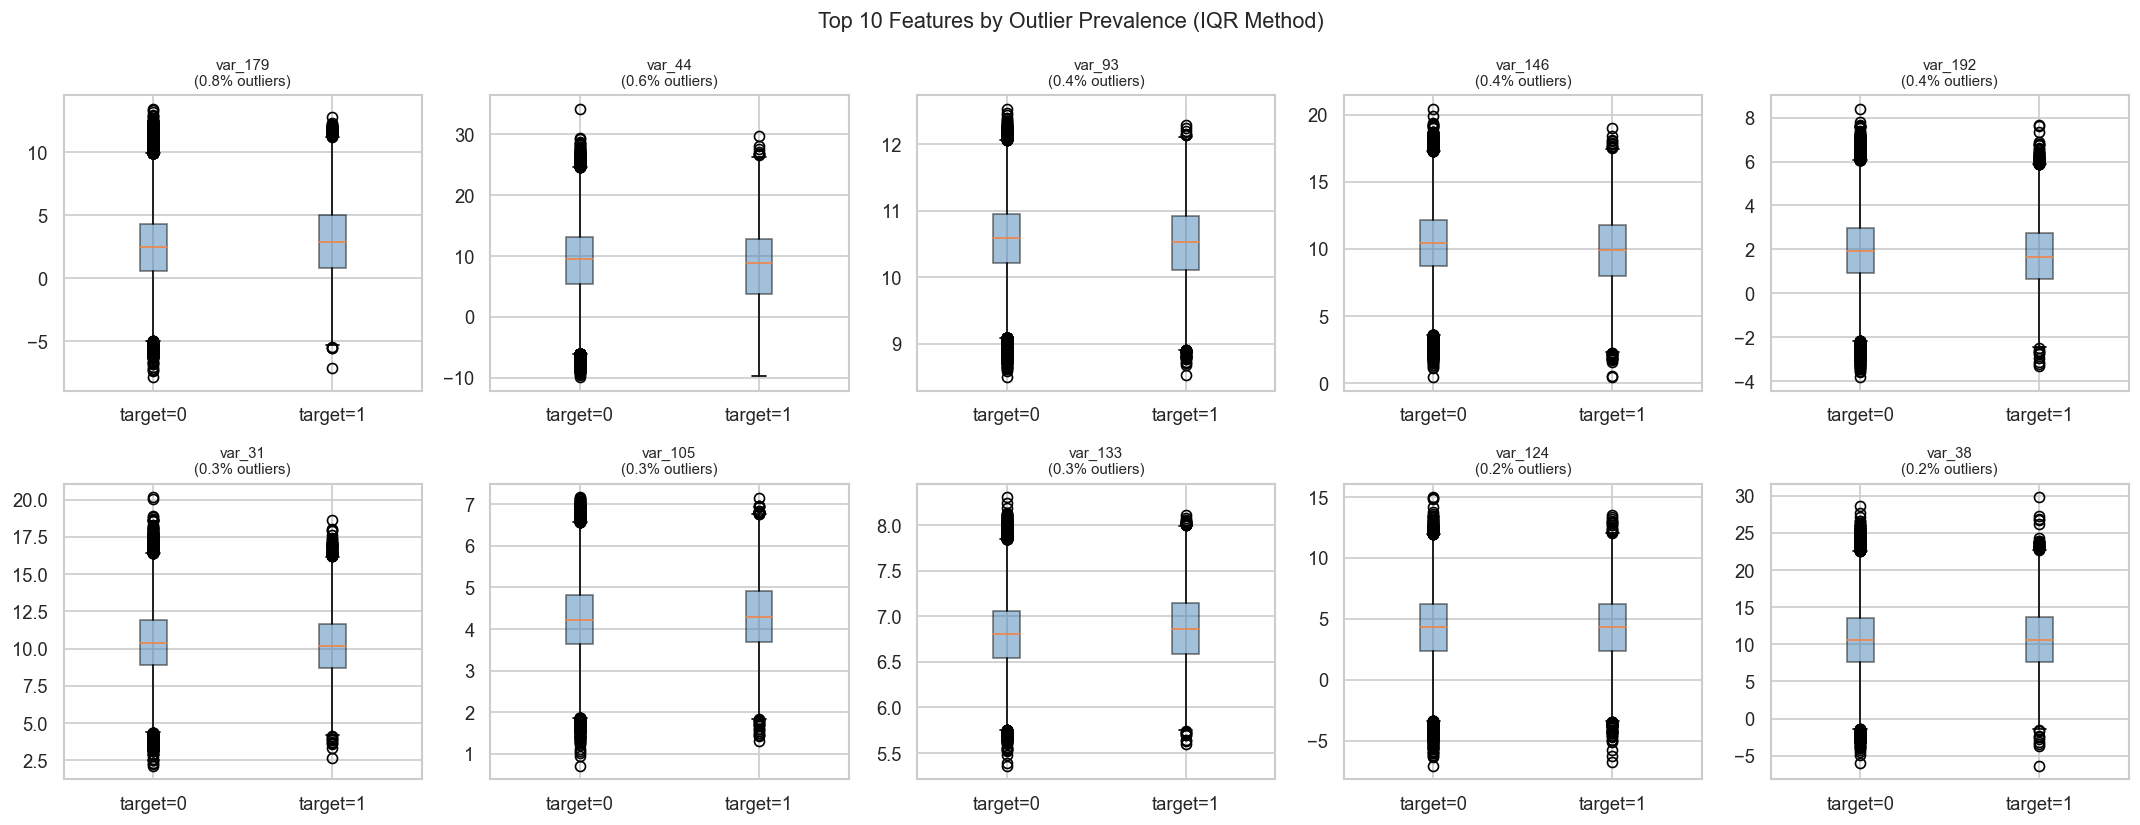

In [16]:
# Boxplots for top 10 most-outlier-prone features
top_outlier_features = outlier_pct.sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(top_outlier_features):
    axes[i].boxplot([df[df.target==0][feat].dropna(),
                     df[df.target==1][feat].dropna()],
                    labels=['target=0', 'target=1'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(f'{feat}\n({outlier_pct[feat]:.1f}% outliers)', fontsize=9)

plt.suptitle('Top 10 Features by Outlier Prevalence (IQR Method)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks_images/04_outlier_boxplots.png', bbox_inches='tight')
plt.show()

**Findings:**
- Outliers exist but are **consistent with real financial data** — not data errors
- Tree-based models (LightGBM) are **robust to outliers** — no clipping needed
- If using logistic regression as baseline, consider **RobustScaler** instead of StandardScaler

## 6. Feature–Target Relationship

In [17]:
# Pearson correlation with target
target_corr = df[feature_cols].corrwith(df['target']).abs().sort_values(ascending=False)

print('Top 15 features most correlated with target:')
print(target_corr.head(15).round(4).to_string())
print(f'\nCorrelation stats:')
print(f'  Max |corr|: {target_corr.max():.4f}  ({target_corr.idxmax()})')
print(f'  Mean |corr|: {target_corr.mean():.4f}')
print(f'  Features with |corr| > 0.05: {(target_corr > 0.05).sum()}')

Top 15 features most correlated with target:
var_81     0.0809
var_139    0.0741
var_12     0.0695
var_6      0.0667
var_110    0.0643
var_146    0.0636
var_53     0.0634
var_26     0.0624
var_76     0.0619
var_174    0.0617
var_22     0.0606
var_21     0.0585
var_99     0.0584
var_166    0.0578
var_80     0.0576

Correlation stats:
  Max |corr|: 0.0809  (var_81)
  Mean |corr|: 0.0279
  Features with |corr| > 0.05: 27


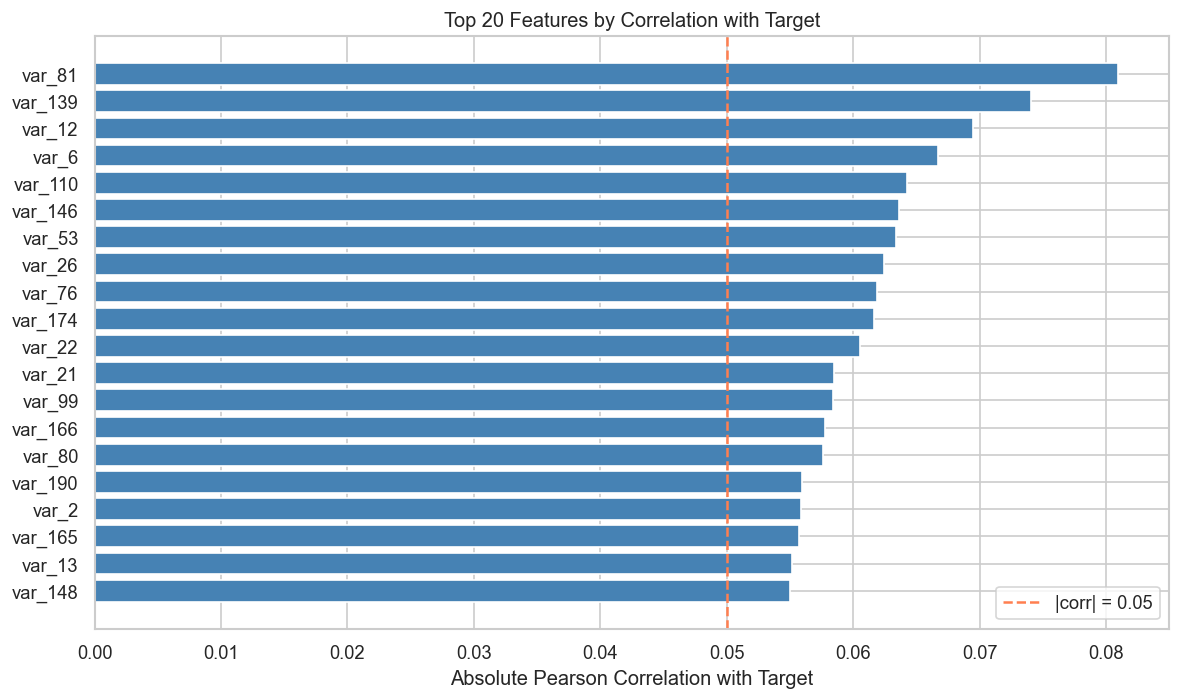

In [18]:
# Bar chart of top 20 features by target correlation
top20 = target_corr.head(20)

plt.figure(figsize=(10, 6))
bars = plt.barh(top20.index[::-1], top20.values[::-1],
                color='steelblue', edgecolor='white')
plt.axvline(0.05, color='coral', linestyle='--', label='|corr| = 0.05')
plt.xlabel('Absolute Pearson Correlation with Target')
plt.title('Top 20 Features by Correlation with Target')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks_images/05_feature_target_correlation.png', bbox_inches='tight')
plt.show()

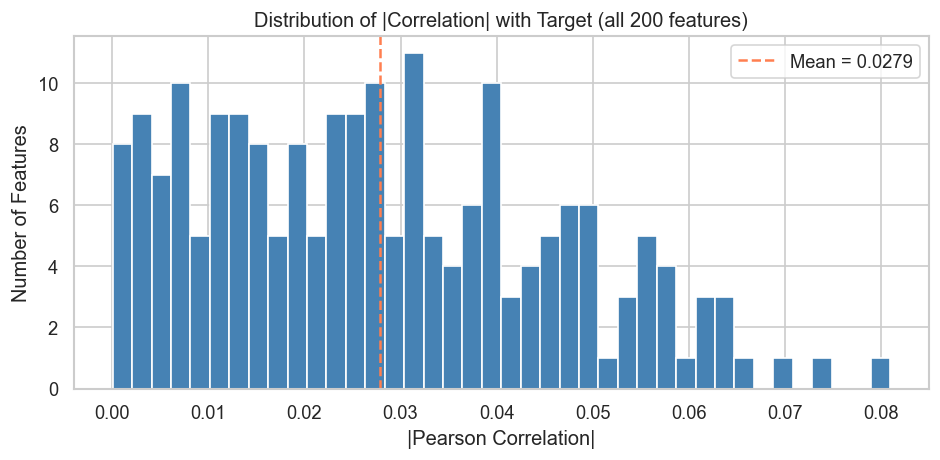

In [19]:
# Distribution of all 200 correlations
plt.figure(figsize=(8, 4))
plt.hist(target_corr, bins=40, color='steelblue', edgecolor='white')
plt.axvline(target_corr.mean(), color='coral', linestyle='--',
            label=f'Mean = {target_corr.mean():.4f}')
plt.title('Distribution of |Correlation| with Target (all 200 features)')
plt.xlabel('|Pearson Correlation|')
plt.ylabel('Number of Features')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks_images/06_corr_distribution.png', bbox_inches='tight')
plt.show()

In [20]:
# Mean difference between classes for top discriminative features
means_0 = df[df.target == 0][feature_cols].mean()
means_1 = df[df.target == 1][feature_cols].mean()
mean_diff = (means_1 - means_0).abs().sort_values(ascending=False)

print('Top 10 features by mean difference between classes:')
comparison = pd.DataFrame({
    'Mean (target=0)': means_0[mean_diff.head(10).index].round(4),
    'Mean (target=1)': means_1[mean_diff.head(10).index].round(4),
    'Abs Difference':  mean_diff.head(10).round(4)
})
print(comparison.to_string())

Top 10 features by mean difference between classes:
         Mean (target=0)  Mean (target=1)  Abs Difference
var_139           7.9505           6.0566          1.8939
var_76            6.2152           4.5803          1.6349
var_149           5.4605           3.8260          1.6345
var_21           17.4181          15.8237          1.5944
var_184          12.6062          14.1037          1.4975
var_174          20.3578          18.8940          1.4638
var_45          -12.5561         -13.9846          1.4285
var_80            5.9382           4.5133          1.4250
var_40           -6.8626          -5.4986          1.3639
var_90          -16.6774         -15.3914          1.2860


**Findings:**
- No single feature is strongly predictive (max |corr| ≈ 0.08) — signal is **distributed across many features**
- Top features: `var_81`, `var_139`, `var_12`, `var_6`, `var_110`
- This is characteristic of ensemble-friendly datasets — **LightGBM** should perform well
- Individual feature correlations are low but collectively informative

## 7. Inter-Feature Correlations

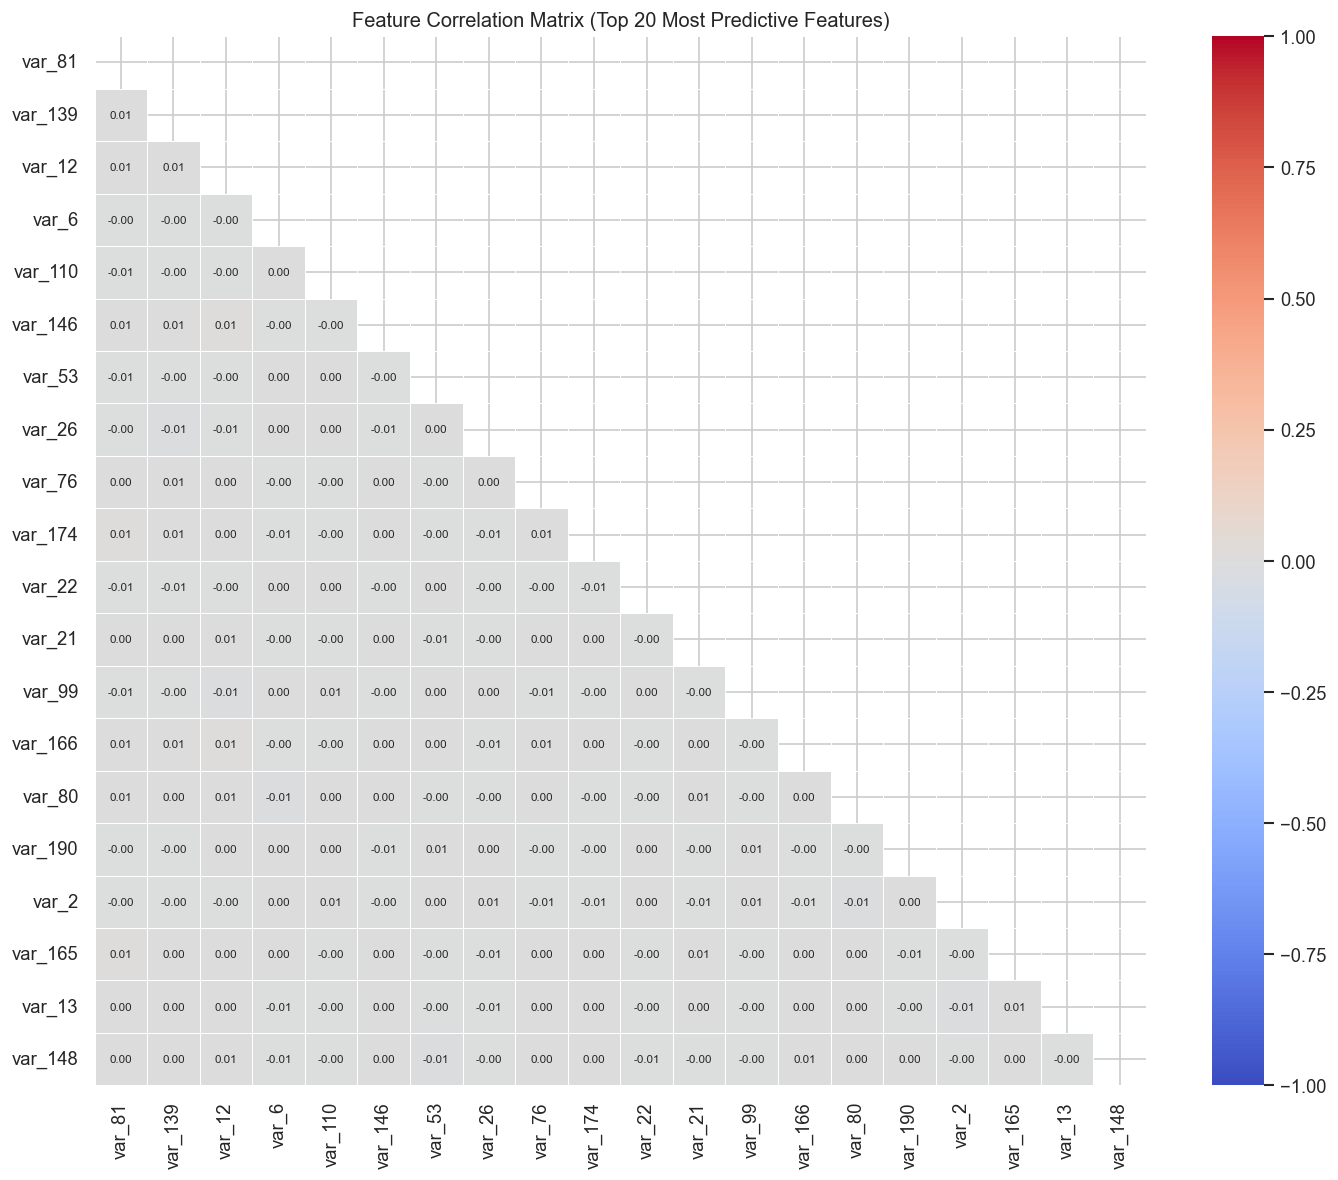

In [21]:
# Correlation matrix of top 20 most predictive features
top20_features = target_corr.head(20).index.tolist()
corr_matrix = df[top20_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Top 20 Most Predictive Features)', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks_images/07_feature_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [22]:
# Check for highly correlated feature pairs across ALL 200 features
full_corr = df[feature_cols].corr().abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.8]

print(f'Feature pairs with |corr| > 0.80: {len(high_corr_pairs)}')
if high_corr_pairs:
    for f1, f2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2])[:10]:
        print(f'  {f1} ↔ {f2}: {corr_val:.4f}')
else:
    print('  → No highly correlated feature pairs found.')

Feature pairs with |corr| > 0.80: 0
  → No highly correlated feature pairs found.


**Findings:**
- Features are largely **independent of each other** — no multicollinearity issues
- No feature pairs with |corr| > 0.80 → **no features need to be dropped** due to redundancy
- This is consistent with Santander anonymizing/decorrelating the features intentionally

## 8. EDA Summary & Findings

| # | Finding | Implication for Modeling |
|---|---------|---------------------------|
| 1 | **Zero missing values** | No imputation needed |
| 2 | **No duplicate rows** | Data is clean |
| 3 | **Severe class imbalance (~90/10)** | Use AUC-ROC; consider `class_weight='balanced'` or SMOTE |
| 4 | **All features normally distributed** | No log transforms needed; StandardScaler sufficient for linear models |
| 5 | **No highly skewed features** | Feature engineering focus: interactions, aggregations |
| 6 | **Outliers present but realistic** | Use RobustScaler for linear baseline; LightGBM handles natively |
| 7 | **Low individual feature–target correlation (max ~0.08)** | Signal is distributed → ensemble methods preferred |
| 8 | **No inter-feature multicollinearity** | All 200 features can be retained; no dropping needed |
| 9 | **Top predictive features**: `var_81`, `var_139`, `var_12`, `var_6`, `var_110` | Useful for feature importance validation in modeling |

### Recommended Next Steps (`02_feature_engineering.ipynb`)
- Scale features for logistic regression baseline (RobustScaler)
- Engineer aggregate features: row-wise mean, std, min, max across all 200 vars
- Apply 80/20 train/validation split (stratified on target)
- Address class imbalance: start with `class_weight='balanced'`, optionally SMOTE